## Define KPIs 
#### (geometric compounding)

In [4]:
import pandas as pd
import numpy as np

# --- Module 1: Configuration ---
CONFIG = {
    'risk_free_rate': 0.0
}

# --- Module 2: Performance Metrics Calculation ---
def calculate_performance_metrics(returns_series: pd.Series, freq: str = '1H') -> dict:
    """
    Calculates a dictionary of performance metrics based on a series of returns,
    using true geometric compounding for cumulative & annualized returns.

    Args:
        returns_series (pd.Series): periodic (e.g. hourly/daily) simple returns R_t.
        freq (str): data frequency for annualization ('1H','4H','1D', etc).

    Returns:
        dict: KPI metrics including Cumulative Return, CAGR, volatility, ratios, etc.
    """
    # handle empty series
    if returns_series.empty:
        return {
            'Cumulative Return':      0.0,
            'Annualized Return':      0.0,
            'Annualized Volatility':  0.0,
            'Sharpe Ratio':           0.0,
            'Sortino Ratio':          0.0,
            'Maximum Drawdown':       0.0,
            'Calmar Ratio':           0.0,
            'Kelly Criterion':        0.0
        }

    # --- determine periods per year ---
    f = freq.upper()
    if 'H' in f:
        periods_per_year = 24 * 365 / int(f.replace('H',''))
    elif 'D' in f:
        periods_per_year = 252
    else:
        periods_per_year = 24 * 365

    # number of observations
    n_periods = returns_series.shape[0]

    # --- Cumulative Return (geometric) ---
    cumulative_return = (1 + returns_series).prod() - 1

    # --- Annualized Return (CAGR) ---
    # (1 + total_return)^(periods_per_year / n_periods) - 1
    total_return = 1 + cumulative_return
    annualized_return = total_return ** (periods_per_year / n_periods) - 1

    # --- Annualized Volatility ---
    annualized_volatility = returns_series.std(ddof=1) * np.sqrt(periods_per_year)

    # --- Sharpe Ratio (using CAGR) ---
    excess_return = annualized_return - CONFIG['risk_free_rate']
    sharpe_ratio = excess_return / annualized_volatility if annualized_volatility != 0 else 0.0

    # --- Sortino Ratio ---
    downside = returns_series[returns_series < 0]
    downside_dev = (
        downside.std(ddof=1) * np.sqrt(periods_per_year)
        if not downside.empty else 0.0
    )
    sortino_ratio = excess_return / downside_dev if downside_dev != 0 else 0.0

    # --- Equity curve & Max Drawdown ---
    equity_curve = (1 + returns_series).cumprod()
    running_max   = equity_curve.cummax()
    drawdown      = (equity_curve - running_max) / running_max
    max_drawdown  = drawdown.min()

    # --- Calmar Ratio ---
    calmar_ratio = (
        annualized_return / abs(max_drawdown)
        if max_drawdown != 0 else 0.0
    )

    # --- Kelly Criterion ---
    traded = returns_series[returns_series != 0]
    if not traded.empty:
        wins   = traded[traded > 0]
        losses = traded[traded < 0]
        W = len(wins) / len(traded)
        avg_win  = wins.mean() if len(wins)  else 0.0
        avg_loss = losses.mean() if len(losses) else 0.0
        R = avg_win / abs(avg_loss) if avg_loss != 0 else np.inf
        kelly = W - (1 - W) / R if (R > 0 and R != np.inf) else 0.0
    else:
        kelly = 0.0

    return {
        'Cumulative Return':      cumulative_return,
        'Annualized Return':      annualized_return,
        'Annualized Volatility':  annualized_volatility,
        'Sharpe Ratio':           sharpe_ratio,
        'Sortino Ratio':          sortino_ratio,
        'Maximum Drawdown':       max_drawdown,
        'Calmar Ratio':           calmar_ratio,
        'Kelly Criterion':        kelly
    }

## Logistic Regression
### Compare strategies (each conin & equal-weight portfolio): 
#### buy_and_hold, long_only, mean_reversion, long_short, trend_following

Saved KPIs for 1min to backtest/KPIs/KPIs_1min.csv
Saved KPIs for 10min to backtest/KPIs/KPIs_10min.csv
Saved KPIs for 1h to backtest/KPIs/KPIs_1h.csv
Saved KPIs for 1d to backtest/KPIs/KPIs_1d.csv
Saved cumulative return for BNBUSDT at 1min to backtest/cum_return/1min/BNBUSDT_cum_return_1min.csv


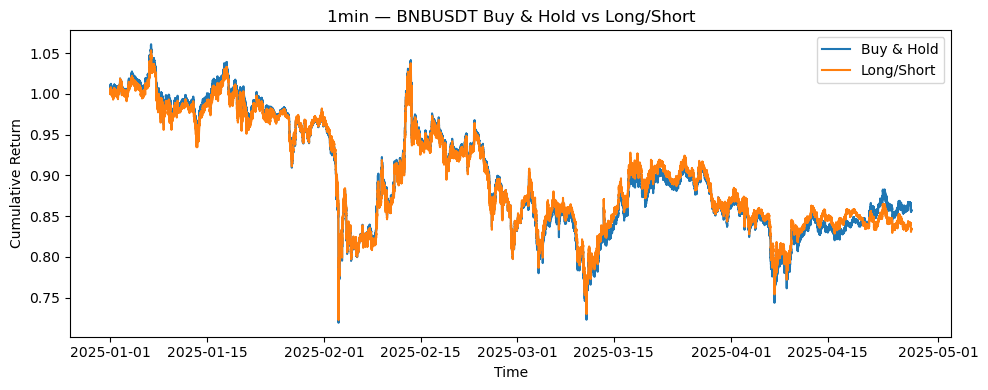

=== KPIs for BNBUSDT at 1min ===
              Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold            -0.1421            -0.0080                 0.0762       -0.1050        -0.1306           -0.3221       -0.0248          -0.0012
long_short              -0.1649            -0.0094                 0.0762       -0.1234        -0.1535           -0.3141       -0.0299          -0.0015
Saved cumulative return for BTCUSDT at 1min to backtest/cum_return/1min/BTCUSDT_cum_return_1min.csv


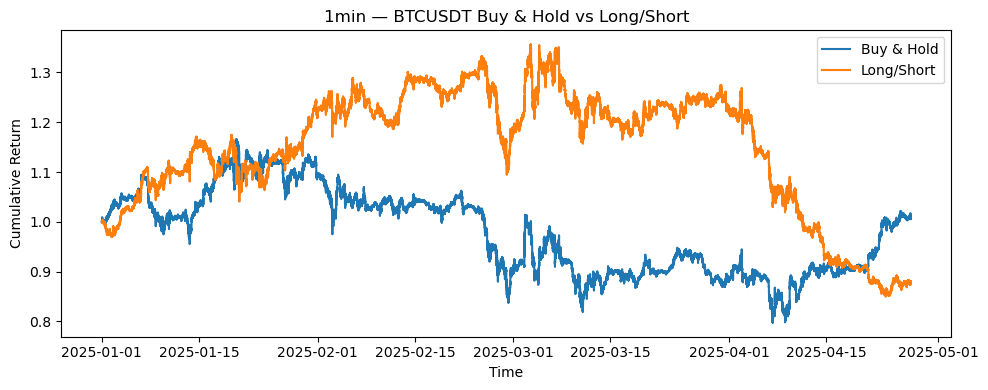

=== KPIs for BTCUSDT at 1min ===
              Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold             0.0079             0.0004                 0.0735        0.0056         0.0072           -0.3167        0.0013           0.0007
long_short              -0.1217            -0.0068                 0.0735       -0.0922        -0.1173           -0.3738       -0.0181          -0.0010
Saved cumulative return for ETHUSDT at 1min to backtest/cum_return/1min/ETHUSDT_cum_return_1min.csv


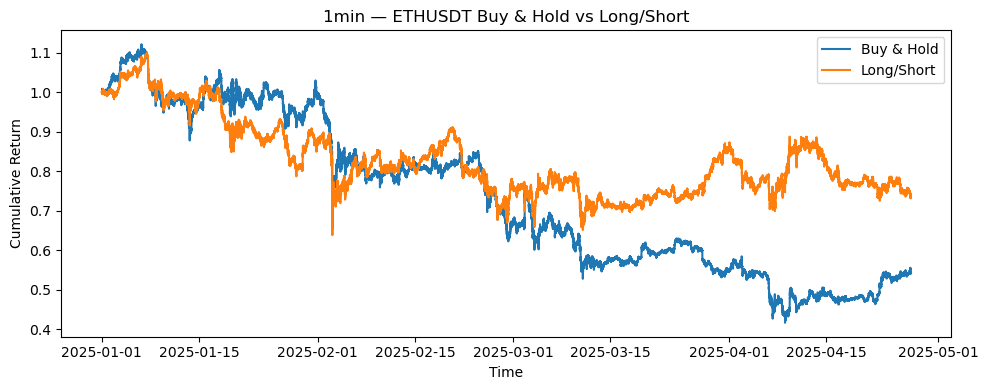

=== KPIs for ETHUSDT at 1min ===
              Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold            -0.4568            -0.0315                 0.1115       -0.2822        -0.3456           -0.6288       -0.0500          -0.0041
long_short              -0.2634            -0.0159                 0.1115       -0.1425        -0.1668           -0.4194       -0.0379          -0.0016
Saved cumulative return for SOLUSDT at 1min to backtest/cum_return/1min/SOLUSDT_cum_return_1min.csv


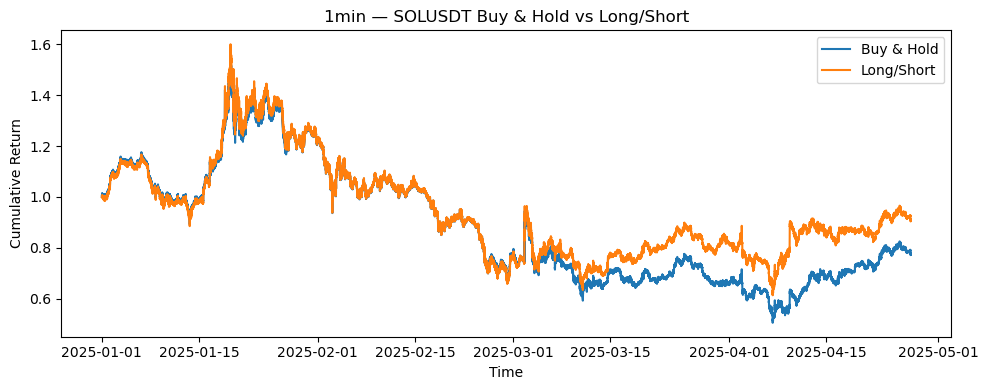

=== KPIs for SOLUSDT at 1min ===
              Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold            -0.2246            -0.0132                 0.1397       -0.0948        -0.1268           -0.6762       -0.0196          -0.0004
long_short              -0.0911            -0.0050                 0.1397       -0.0357        -0.0477           -0.6170       -0.0081           0.0006
Saved cumulative return for XRPUSDT at 1min to backtest/cum_return/1min/XRPUSDT_cum_return_1min.csv


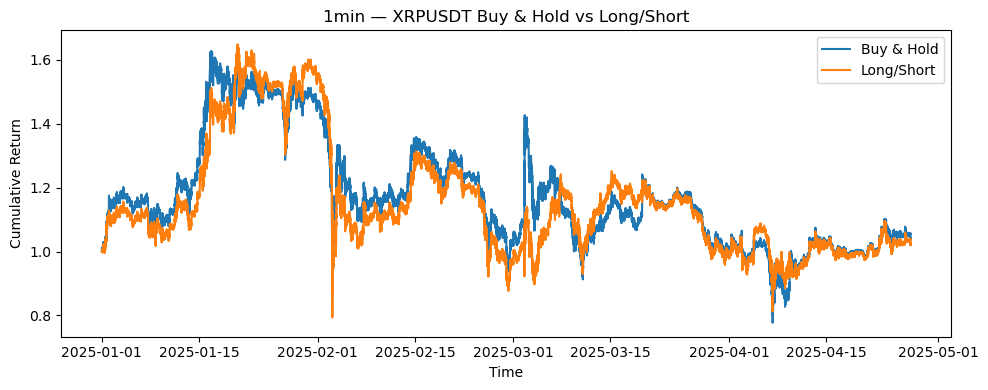

=== KPIs for XRPUSDT at 1min ===
              Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold             0.0420             0.0022                 0.1478        0.0146         0.0191           -0.5228        0.0041           0.0015
long_short               0.0244             0.0013                 0.1478        0.0086         0.0110           -0.5187        0.0024           0.0014
Saved cumulative return for Portfolio at 1min to backtest/cum_return/1min/Portfolio_cum_return_1min.csv


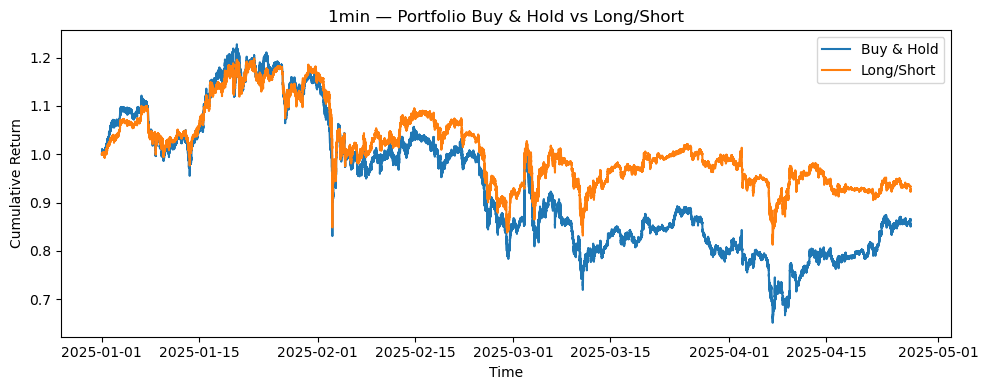

=== KPIs for Portfolio at 1min ===
              Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold            -0.1458            -0.0082                 0.0960       -0.0857        -0.1108           -0.4693       -0.0175          -0.0006
long_short              -0.0734            -0.0040                 0.0812       -0.0491        -0.0588           -0.3216       -0.0124          -0.0002
Saved cumulative return for BNBUSDT at 10min to backtest/cum_return/10min/BNBUSDT_cum_return_10min.csv


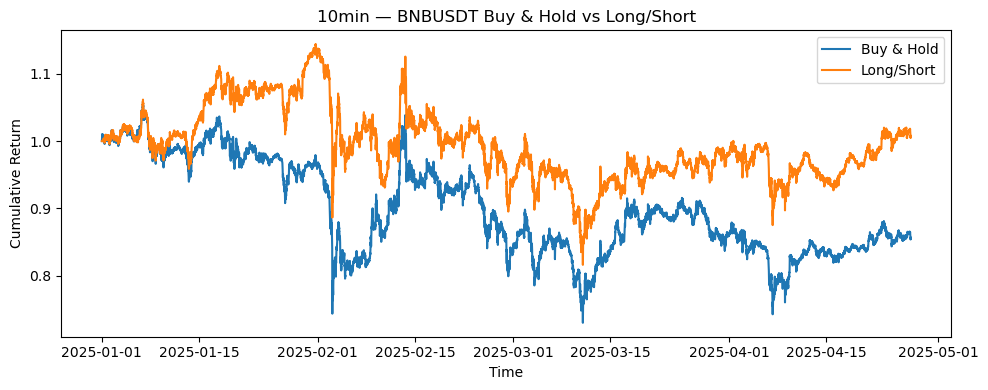

=== KPIs for BNBUSDT at 10min ===
              Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold            -0.1438            -0.0781                 0.2395       -0.3262        -0.4173           -0.3103       -0.2517          -0.0037
long_short               0.0077             0.0041                 0.2394        0.0169         0.0213           -0.2869        0.0141           0.0023
Saved cumulative return for BTCUSDT at 10min to backtest/cum_return/10min/BTCUSDT_cum_return_10min.csv


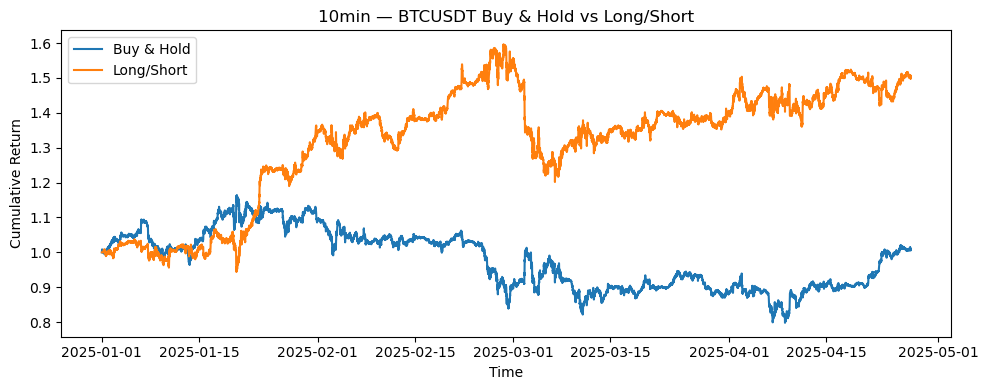

=== KPIs for BTCUSDT at 10min ===
              Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold             0.0079             0.0041                 0.2291        0.0180         0.0237           -0.3147        0.0131           0.0022
long_short               0.5014             0.2372                 0.2290        1.0362         1.3163           -0.2473        0.9593           0.0175
Saved cumulative return for ETHUSDT at 10min to backtest/cum_return/10min/ETHUSDT_cum_return_10min.csv


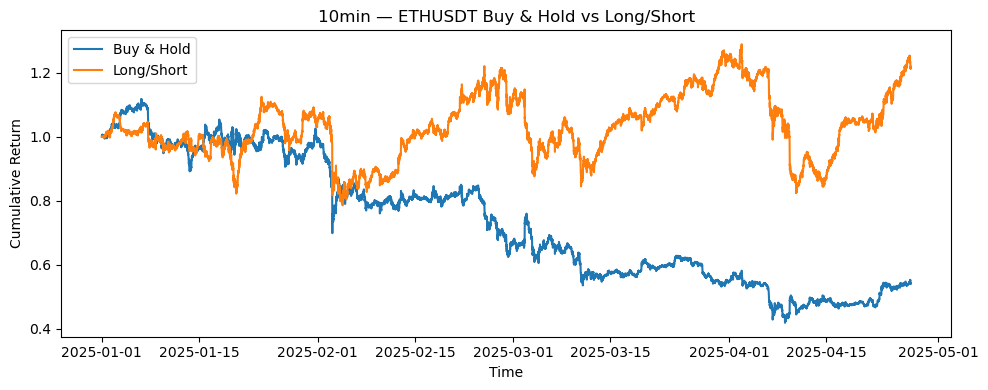

=== KPIs for ETHUSDT at 10min ===
              Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold            -0.4576            -0.2742                 0.3406       -0.8051        -1.0212           -0.6259       -0.4381          -0.0133
long_short               0.2177             0.1087                 0.3405        0.3191         0.3737           -0.3609        0.3011           0.0083
Saved cumulative return for SOLUSDT at 10min to backtest/cum_return/10min/SOLUSDT_cum_return_10min.csv


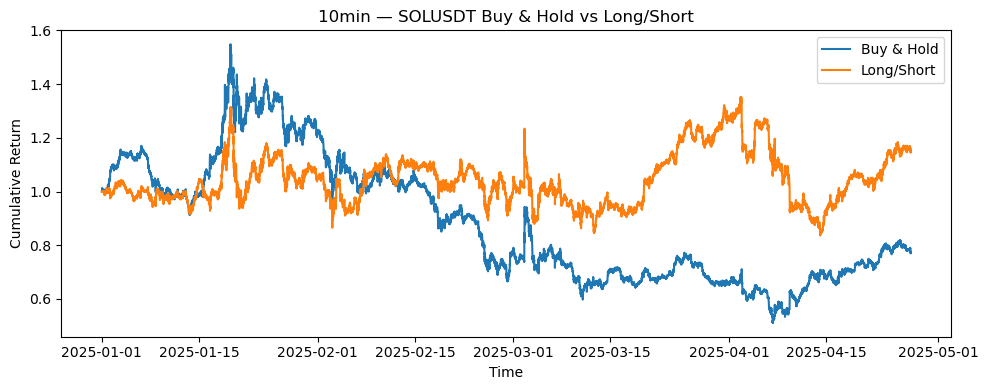

=== KPIs for SOLUSDT at 10min ===
              Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold            -0.2259            -0.1255                 0.4414       -0.2844        -0.3977           -0.6698       -0.1874          -0.0014
long_short               0.1515             0.0767                 0.4413        0.1738         0.2304           -0.3812        0.2012           0.0064
Saved cumulative return for XRPUSDT at 10min to backtest/cum_return/10min/XRPUSDT_cum_return_10min.csv


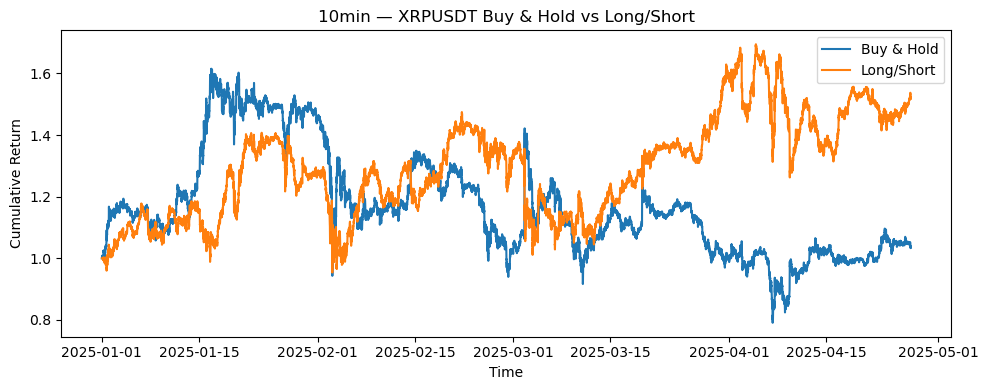

=== KPIs for XRPUSDT at 10min ===
              Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold             0.0381             0.0198                 0.4691        0.0422         0.0578           -0.5104        0.0388           0.0047
long_short               0.5239             0.2469                 0.4691        0.5264         0.6403           -0.3222        0.7663           0.0123
Saved cumulative return for Portfolio at 10min to backtest/cum_return/10min/Portfolio_cum_return_10min.csv


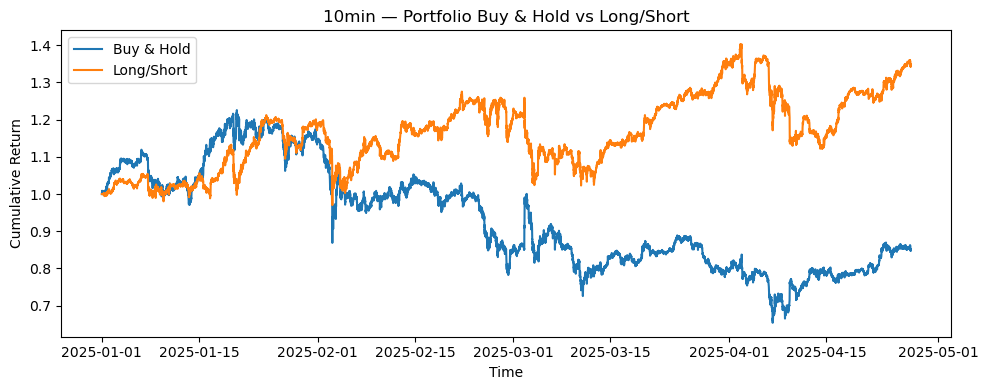

=== KPIs for Portfolio at 10min ===
              Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold            -0.1492            -0.0811                 0.3038       -0.2670        -0.3539           -0.4664       -0.1740          -0.0021
long_short               0.3474             0.1691                 0.2483        0.6810         0.7936           -0.2001        0.8450           0.0145
Saved cumulative return for BNBUSDT at 1h to backtest/cum_return/1h/BNBUSDT_cum_return_1h.csv


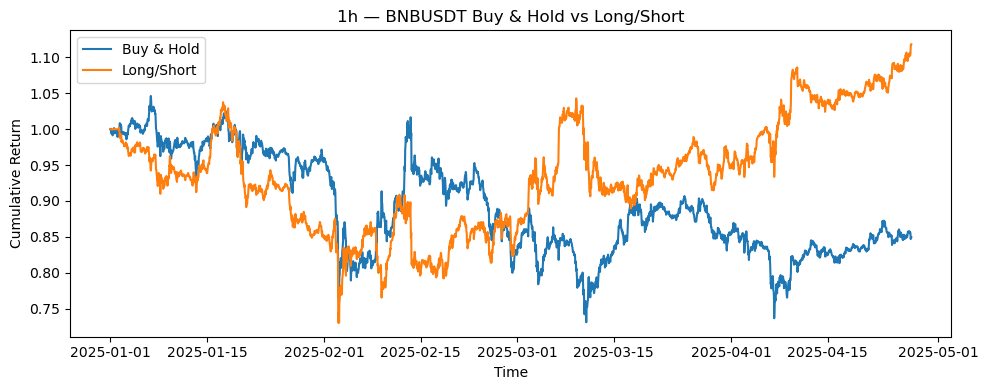

=== KPIs for BNBUSDT at 1h ===
              Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold            -0.1505            -0.4009                 0.5852       -0.6851        -0.8285           -0.3014       -1.3302          -0.0097
long_short               0.1184             0.4214                 0.5844        0.7210         0.8606           -0.2963        1.4222           0.0148
Saved cumulative return for BTCUSDT at 1h to backtest/cum_return/1h/BTCUSDT_cum_return_1h.csv


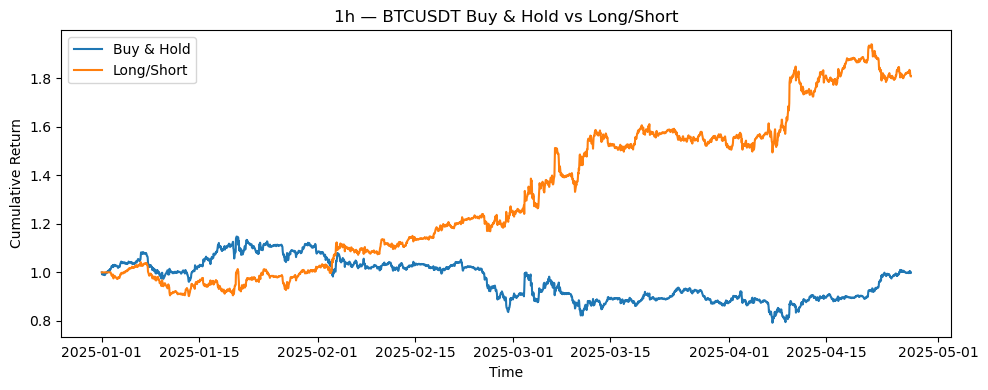

=== KPIs for BTCUSDT at 1h ===
              Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold            -0.0006            -0.0018                 0.5574       -0.0033        -0.0042           -0.3094       -0.0059           0.0046
long_short               0.8070             5.4181                 0.5561        9.7428        13.4172           -0.1341       40.3924           0.0601
Saved cumulative return for ETHUSDT at 1h to backtest/cum_return/1h/ETHUSDT_cum_return_1h.csv


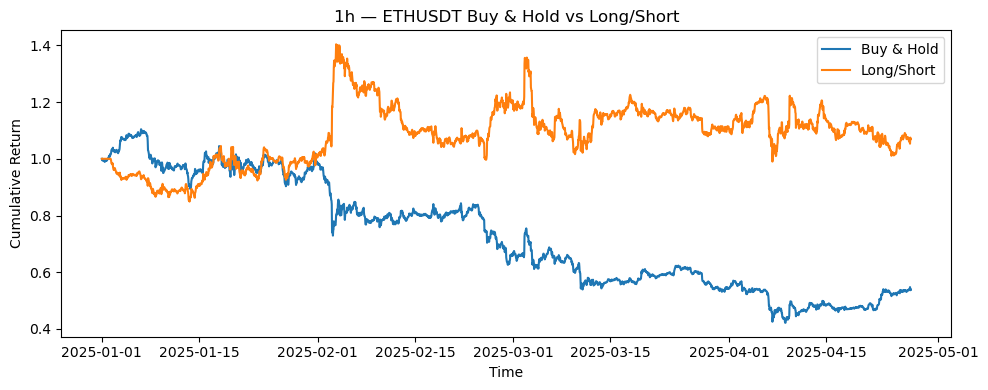

=== KPIs for ETHUSDT at 1h ===
              Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold            -0.4609            -0.8565                 0.8384       -1.0216        -1.2206           -0.6180       -1.3859          -0.0334
long_short               0.0695             0.2352                 0.8380        0.2807         0.3846           -0.2947        0.7982           0.0112
Saved cumulative return for SOLUSDT at 1h to backtest/cum_return/1h/SOLUSDT_cum_return_1h.csv


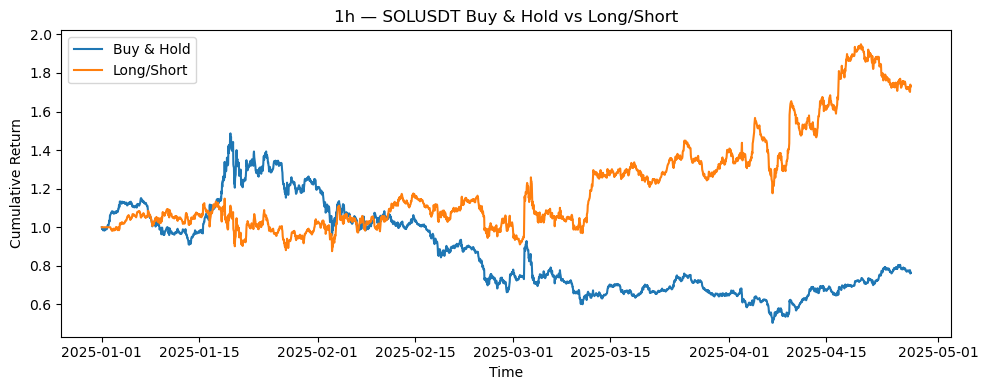

=== KPIs for SOLUSDT at 1h ===
              Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold            -0.2361            -0.5709                 1.0907       -0.5234        -0.7346           -0.6606       -0.8642          -0.0037
long_short               0.7306             4.6027                 1.0881        4.2302         5.9405           -0.2493       18.4652           0.0333
Saved cumulative return for XRPUSDT at 1h to backtest/cum_return/1h/XRPUSDT_cum_return_1h.csv


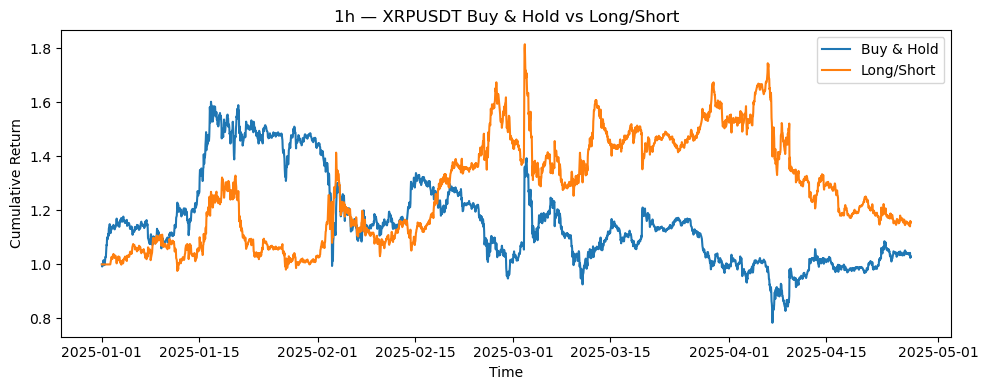

=== KPIs for XRPUSDT at 1h ===
              Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold             0.0293             0.0949                 1.1306        0.0840         0.1157           -0.5104        0.1860           0.0107
long_short               0.1551             0.5732                 1.1254        0.5093         0.6524           -0.3712        1.5441           0.0168
Saved cumulative return for Portfolio at 1h to backtest/cum_return/1h/Portfolio_cum_return_1h.csv


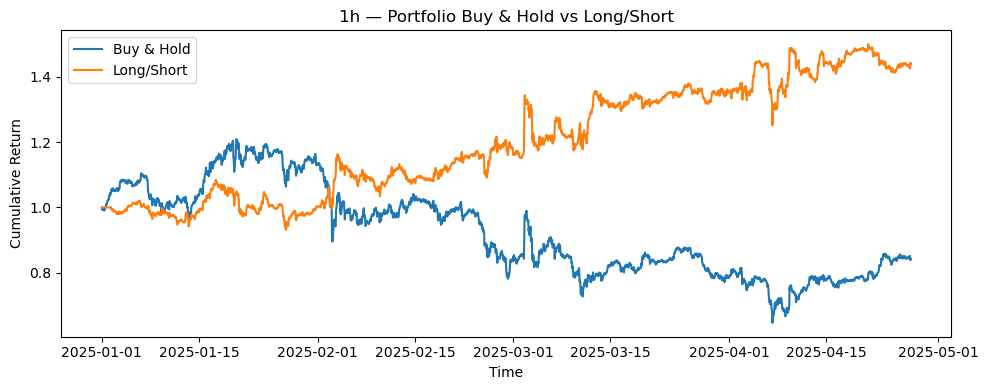

=== KPIs for Portfolio at 1h ===
              Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold            -0.1575            -0.4163                 0.7450       -0.5588        -0.7033           -0.4640       -0.8973          -0.0059
long_short               0.4381             2.1316                 0.5617        3.7951         4.8450           -0.1413       15.0812           0.0414
Saved cumulative return for BNBUSDT at 1d to backtest/cum_return/1d/BNBUSDT_cum_return_1d.csv


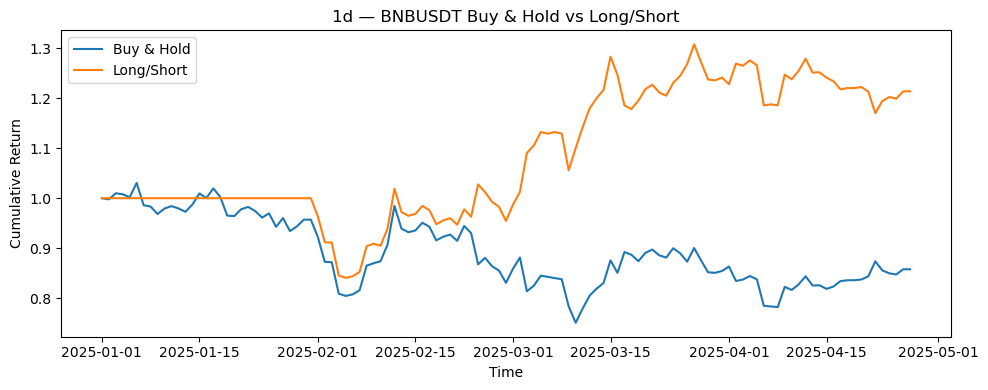

=== KPIs for BNBUSDT at 1d ===
              Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold            -0.1421            -0.2812                 0.4195       -0.6703        -0.8877           -0.2714       -1.0364          -0.0524
long_short               0.2138             0.5178                 0.3950        1.3110         1.6832           -0.1593        3.2501           0.1213
Saved cumulative return for BTCUSDT at 1d to backtest/cum_return/1d/BTCUSDT_cum_return_1d.csv


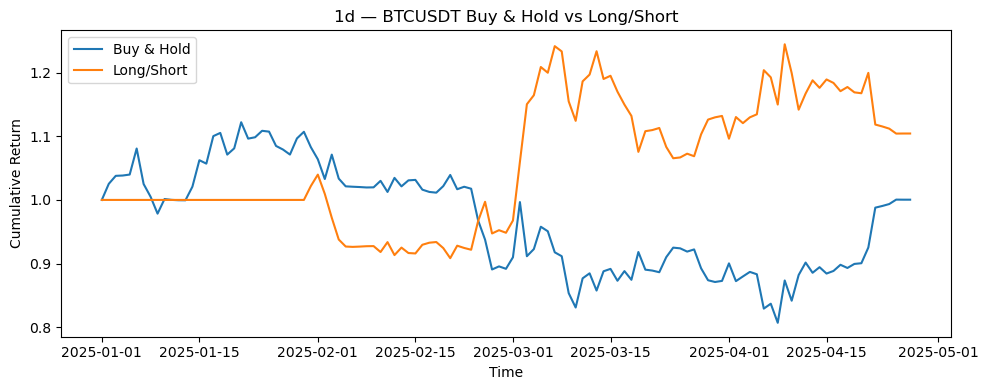

=== KPIs for BTCUSDT at 1d ===
              Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold             0.0004             0.0008                 0.4379        0.0019         0.0028           -0.2810        0.0029           0.0190
long_short               0.1044             0.2385                 0.3994        0.5971         0.8484           -0.1419        1.6805           0.0728
Saved cumulative return for ETHUSDT at 1d to backtest/cum_return/1d/ETHUSDT_cum_return_1d.csv


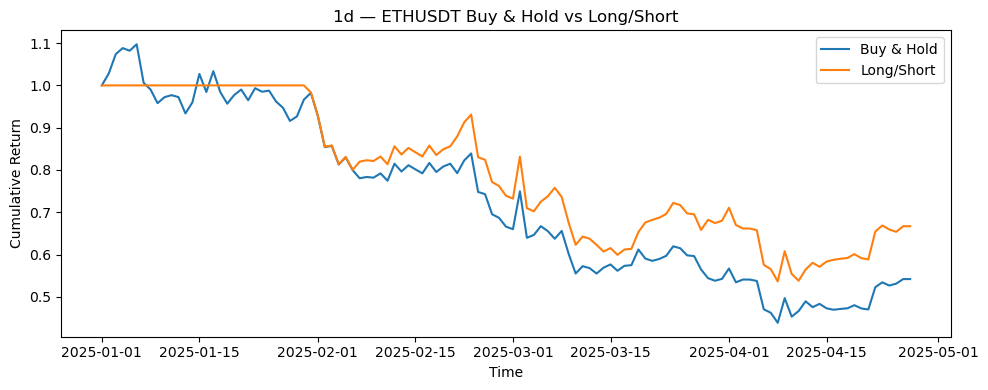

=== KPIs for ETHUSDT at 1d ===
              Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold            -0.4581            -0.7328                 0.6775       -1.0816        -1.4916           -0.6004       -1.2205          -0.1544
long_short              -0.3331            -0.5821                 0.6257       -0.9303        -1.0657           -0.4636       -1.2555          -0.1213
Saved cumulative return for SOLUSDT at 1d to backtest/cum_return/1d/SOLUSDT_cum_return_1d.csv


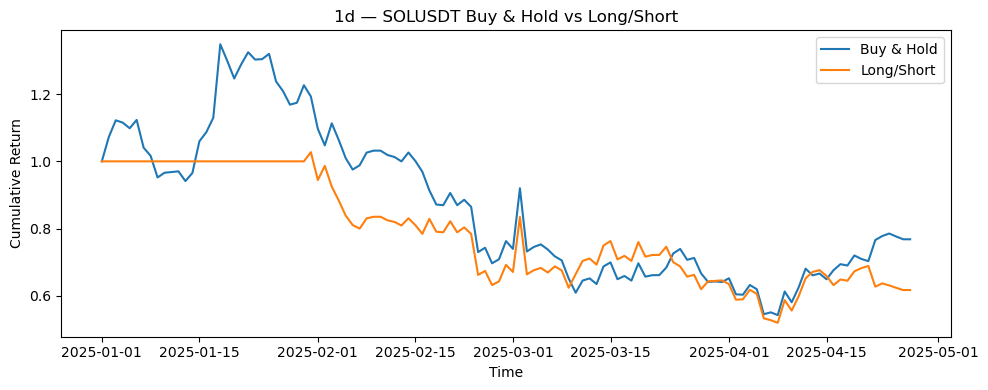

=== KPIs for SOLUSDT at 1d ===
              Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold            -0.2319            -0.4335                 0.9019       -0.4807        -0.7528           -0.5977       -0.7254          -0.0170
long_short              -0.3830            -0.6466                 0.7960       -0.8123        -1.0069           -0.4943       -1.3080          -0.1022
Saved cumulative return for XRPUSDT at 1d to backtest/cum_return/1d/XRPUSDT_cum_return_1d.csv


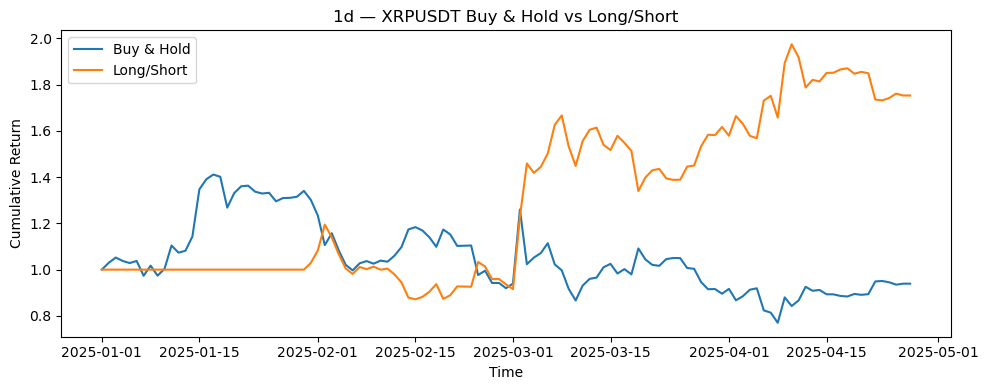

=== KPIs for XRPUSDT at 1d ===
              Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold            -0.0607            -0.1263                 0.9171       -0.1377        -0.2249           -0.4543       -0.2779           0.0294
long_short               0.7531             2.3504                 0.8230        2.8558         5.5726           -0.2706        8.6846           0.1864
Saved cumulative return for Portfolio at 1d to backtest/cum_return/1d/Portfolio_cum_return_1d.csv


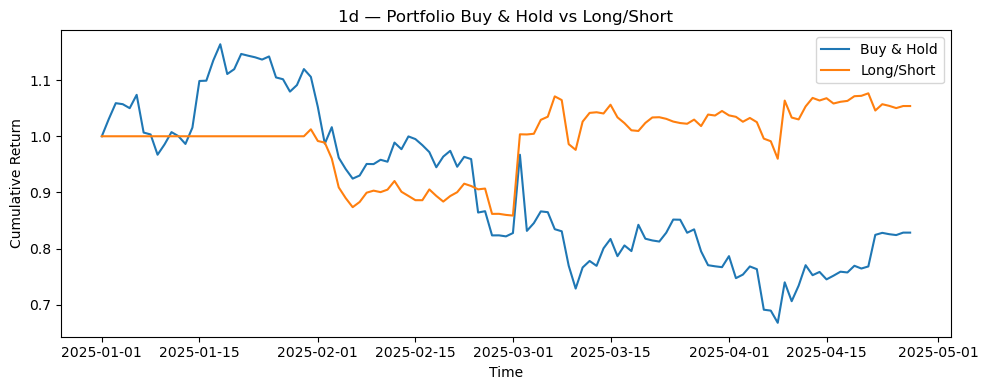

=== KPIs for Portfolio at 1d ===
              Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold            -0.1716            -0.3333                 0.5980       -0.5573        -0.7508           -0.4262       -0.7821          -0.0347
long_short               0.0538             0.1196                 0.3819        0.3131         0.4933           -0.1518        0.7879           0.0555


In [21]:
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# (Assume calculate_performance_metrics is defined above in the notebook)
# ---------------------------------------------------------------------------
warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# 1) Configuration
# ---------------------------------------------------------------------------
DATA_ROOT   = os.path.join("..", "data", "resampled")    # directory with test_{interval}.parquet
PRED_ROOT   = "results"                                     # per-coin LR signal files organized by interval
OUTPUT_DIR  = "backtest"                                    # base output directory
INTERVALS   = ["1min", "10min", "1h", "1d"]
STRATEGIES  = ["buy_and_hold", "long_only", "mean_reversion", "long_short", "trend_following"]

# KPI and cumulative-return folders
KPIS_DIR    = os.path.join(OUTPUT_DIR, "KPIs")
CUMRET_DIR  = os.path.join(OUTPUT_DIR, "cum_return")
os.makedirs(KPIS_DIR, exist_ok=True)
os.makedirs(CUMRET_DIR, exist_ok=True)

# ---------------------------------------------------------------------------
# 2) Strategy position generators & backtest engine
# ---------------------------------------------------------------------------
def generate_mean_reversion_positions(data: pd.DataFrame) -> pd.Series:
    w, s = 20, 2.0
    m  = data["close"].rolling(w).mean()
    sd = data["close"].rolling(w).std()
    ub, lb = m + s * sd, m - s * sd
    sig = pd.Series(0, index=data.index)
    sig[data["close"] < lb] = 1
    sig[data["close"] > ub] = -1
    return sig.replace(0, method="ffill").fillna(0)

def generate_buy_and_hold_positions(data: pd.DataFrame) -> pd.Series:
    return pd.Series(1, index=data.index)

def generate_long_only_positions(preds: pd.Series) -> pd.Series:
    return (preds > 0.5).astype(int)

def generate_long_short_positions(preds: pd.Series) -> pd.Series:
    sig = pd.Series(0, index=preds.index)
    sig[preds > 0.5] = 1
    sig[(1 - preds) > 0.5] = -1
    return sig

def generate_trend_following_positions(data: pd.DataFrame, preds: pd.Series) -> pd.Series:
    w = 200
    trend = data["close"].rolling(w).mean()
    sig = pd.Series(0, index=data.index)
    sig[(preds == 1) & (data["close"] > trend)]  = 1
    sig[(preds == -1) & (data["close"] < trend)] = -1
    return sig

def run_vectorized_backtest(data: pd.DataFrame, positions: pd.Series) -> pd.Series:
    ret = data["open"].pct_change().shift(-1)
    pos = positions.shift(1).fillna(0)
    return (pos * ret).fillna(0)

def generate_strategy_positions(name: str, data: pd.DataFrame, preds: pd.Series=None) -> pd.Series:
    if name == "buy_and_hold":    return generate_buy_and_hold_positions(data)
    if name == "long_only":       return generate_long_only_positions(preds)
    if name == "mean_reversion":  return generate_mean_reversion_positions(data)
    if name == "long_short":      return generate_long_short_positions(preds)
    if name == "trend_following": return generate_trend_following_positions(data, preds)
    raise ValueError(f"Unknown strategy: {name}")

def calculate_portfolio_return(name: str, weights: dict, all_data: dict, all_preds: dict) -> pd.Series:
    parts = []
    for coin, w in weights.items():
        data  = all_data[coin]
        preds = all_preds[coin]
        sig   = generate_strategy_positions(name, data, preds)
        net   = run_vectorized_backtest(data, sig)
        parts.append(net * w)
    return pd.concat(parts, axis=1).sum(axis=1) if parts else pd.Series(dtype=float)

# ---------------------------------------------------------------------------
# 3) Compute and save KPIs (flat KPIs folder)
# ---------------------------------------------------------------------------
all_kpi_records = []
for iv in INTERVALS:
    # Load test data
    df_test = pd.read_parquet(os.path.join(DATA_ROOT, f"test_{iv}.parquet"))
    df_test["timestamp"] = pd.to_datetime(df_test["timestamp"])
    coins = df_test["coin_id"].unique().tolist()

    # Prepare all_data and all_preds
    all_data = {
        c: df_test[df_test.coin_id == c].set_index("timestamp")[['open','high','low','close']]
        for c in coins
    }
    all_preds = {}
    for c in coins:
        pf = os.path.join(PRED_ROOT, iv, f"{c}.parquet")
        if os.path.exists(pf):  all_preds[c] = pd.read_parquet(pf)["signal"]
        else:                   all_preds[c] = pd.Series(0, index=all_data[c].index)

    # Equal-weight
    w_eq = {c: 1.0/len(coins) for c in coins}

    kpi_records = []
    # Per-coin
    for c in coins:
        w = {c: 1.0}
        for strat in STRATEGIES:
            ret = calculate_portfolio_return(strat, w, all_data, all_preds)
            k   = calculate_performance_metrics(ret, freq=iv)
            rec = {
                "interval": iv, "entity": c, "strategy": strat,
                "Cumulative Return":     k['Cumulative Return'],
                "Annualized Return":     k['Annualized Return'],
                "Annualized Volatility": k['Annualized Volatility'],
                "Sharpe Ratio":          k['Sharpe Ratio'],
                "Sortino Ratio":         k['Sortino Ratio'],
                "Maximum Drawdown":      k['Maximum Drawdown'],
                "Calmar Ratio":          k['Calmar Ratio'],
                "Kelly Criterion":       k['Kelly Criterion'],
            }
            kpi_records.append(rec)
            all_kpi_records.append(rec)
    # Portfolio
    for strat in STRATEGIES:
        ret = calculate_portfolio_return(strat, w_eq, all_data, all_preds)
        k   = calculate_performance_metrics(ret, freq=iv)
        rec = {
            "interval": iv, "entity": "Portfolio", "strategy": strat,
            "Cumulative Return":     k['Cumulative Return'],
            "Annualized Return":     k['Annualized Return'],
            "Annualized Volatility": k['Annualized Volatility'],
            "Sharpe Ratio":          k['Sharpe Ratio'],
            "Sortino Ratio":         k['Sortino Ratio'],
            "Maximum Drawdown":      k['Maximum Drawdown'],
            "Calmar Ratio":          k['Calmar Ratio'],
            "Kelly Criterion":       k['Kelly Criterion'],
        }
        kpi_records.append(rec)
        all_kpi_records.append(rec)

    df_kpi   = pd.DataFrame(kpi_records)
    file_kpi = os.path.join(KPIS_DIR, f"KPIs_{iv}.csv")
    df_kpi.to_csv(file_kpi, index=False)
    print(f"Saved KPIs for {iv} to {file_kpi}")

# ---------------------------------------------------------------------------
# 4) Plot buy & hold vs long_short per entity and print all KPIs
# ---------------------------------------------------------------------------
for iv in INTERVALS:
    df_test = pd.read_parquet(os.path.join(DATA_ROOT, f"test_{iv}.parquet"))
    df_test["timestamp"] = pd.to_datetime(df_test["timestamp"])
    coins = df_test["coin_id"].unique().tolist()

    all_data = {
        c: df_test[df_test.coin_id == c].set_index('timestamp')[['open','high','low','close']]
        for c in coins
    }
    all_preds = {}
    for c in coins:
        pf = os.path.join(PRED_ROOT, iv, f"{c}.parquet")
        if os.path.exists(pf):  all_preds[c] = pd.read_parquet(pf)["signal"]
        else:                   all_preds[c] = pd.Series(0, index=all_data[c].index)

    w_eq     = {c: 1.0/len(coins) for c in coins}
    entities = coins + ["Portfolio"]

    for ent in entities:
        if ent == "Portfolio":
            data_dict, preds_dict, w = all_data, all_preds, w_eq
        else:
            data_dict, preds_dict, w = {ent: all_data[ent]}, {ent: all_preds[ent]}, {ent: 1.0}

        ret_bh = calculate_portfolio_return("buy_and_hold", w, data_dict, preds_dict)
        ret_ls = calculate_portfolio_return("long_short",   w, data_dict, preds_dict)
        k_bh   = calculate_performance_metrics(ret_bh, freq=iv)
        k_ls   = calculate_performance_metrics(ret_ls, freq=iv)

        cr_bh = (1 + ret_bh).cumprod().rename('buy_and_hold')
        cr_ls = (1 + ret_ls).cumprod().rename('long_short')
        df_cr = pd.concat([cr_bh, cr_ls], axis=1)

        subcr   = os.path.join(CUMRET_DIR, iv)
        os.makedirs(subcr, exist_ok=True)
        file_cr = os.path.join(subcr, f"{ent}_cum_return_{iv}.csv")
        df_cr.to_csv(file_cr, index=True)
        print(f"Saved cumulative return for {ent} at {iv} to {file_cr}")

        plt.figure(figsize=(10, 4))
        plt.plot(df_cr.index, df_cr['buy_and_hold'], label='Buy & Hold')
        plt.plot(df_cr.index, df_cr['long_short'],   label='Long/Short')
        plt.title(f"{iv} — {ent} Buy & Hold vs Long/Short")
        plt.xlabel("Time")
        plt.ylabel("Cumulative Return")
        plt.legend()
        plt.tight_layout()
        plt.show()

        df_k = pd.DataFrame([k_bh, k_ls], index=['buy_and_hold', 'long_short'])
        print(f"=== KPIs for {ent} at {iv} ===")
        print(df_k.to_string(float_format='%.4f'))